In [ ]:
#  Regression & Its Evaluation | Assignment

Q1 What is Simple Linear Regression?
    Simple Linear Regression is a statistical method used to model the relationship between one independent variable (X) and one dependent variable (Y). 
    It fits a straight line to the data to predict the value of the dependent variable based on the independent variable. The equation of a simple linear
    regression line is:
    Y = a + bX
Where:
Y = Dependent variable
X = Independent variable
a = Intercept
b = Slope of the line

Q2 What are the key assumptions of Simple Linear Regression?
    The key assumptions of Simple Linear Regression are:
   - Linearity: There should be a linear relationship between X and Y.
   - Independence: Observations should be independent of each other.
   - Homoscedasticity: The variance of residuals should remain constant.
   - Normality: Residuals should be approximately normally distributed.
   - No Significant Outliers: Extreme values should not strongly influence the model.

Q3 What is heteroscedasticity, and why is it important to address in regression models?
    Heteroscedasticity occurs when the variance of the residuals (errors) is not constant across all levels of the independent variable. 
    In such cases, the spread of errors increases or decreases as the value of X changes.

It is important to address heteroscedasticity because:

-It can lead to inefficient estimates.
-Standard errors may become biased.
-Hypothesis tests and confidence intervals may become unreliable.
-The accuracy of predictions may decrease.

Methods such as data transformation, weighted least squares, and robust standard errors can help reduce heteroscedasticity.

Q4 What is Multiple Linear Regression?
    Multiple Linear Regression is an extension of Simple Linear Regression that uses two or more independent variables to predict a dependent variable.

The general equation is:
Y = a + b₁X₁ + b₂X₂ + ... + bₙXₙ

Where:
Y = Dependent variable
X₁, X₂, ..., Xₙ = Independent variables
a = Intercept
b₁, b₂, ..., bₙ = Regression coefficients

It is widely used to analyze the effect of multiple factors on an outcome and to make more accurate predictions.

Q5 What is polynomial regression, and how does it differ from linear regression?
    Polynomial Regression is a regression technique used when the relationship between the independent and dependent variables is non-linear. 
    It models the relationship using polynomial terms such as X², X³, etc.

A second-degree polynomial regression equation is:
Y = a + b₁X + b₂X²

Difference between Linear and Polynomial Regression:

Linear Regression	                     Polynomial Regression
Fits a straight line	                 Fits a curved line
Models linear relationships	             Models non-linear relationships
Simpler and easier to interpret	         More flexible for complex patterns
Equation: Y = a + bX	                 Equation: Y = a + b₁X + b₂X² + ...


Slope: 1.9800000000000006
Intercept: 0.17999999999999705


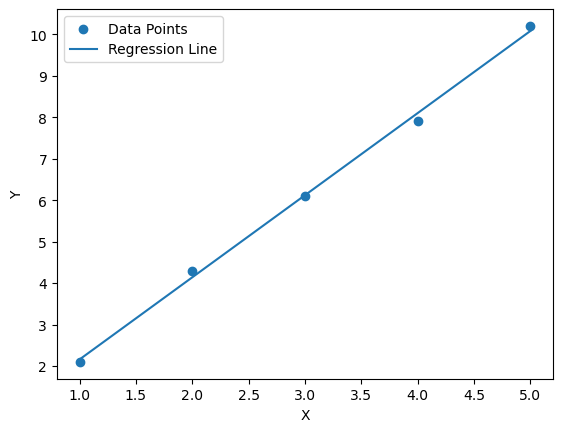

In [1]:
# Q6 : Implement a Python program to fit a Simple Linear Regression model to the following sample data:
# X = [1, 2, 3, 4, 5]
# Y = [2.1, 4.3, 6.1, 7.9, 10.2]
# Plot the regression line over the data points.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([1, 2, 3, 4, 5]).reshape(-1, 1)
Y = np.array([2.1, 4.3, 6.1, 7.9, 10.2])

model = LinearRegression()
model.fit(X, Y)

Y_pred = model.predict(X)

print("Slope:", model.coef_[0])
print("Intercept:", model.intercept_)

plt.scatter(X, Y, label="Data Points")
plt.plot(X, Y_pred, label="Regression Line")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()

In [2]:
# Q7 Fit a Multiple Linear Regression model on this sample data:
# Area = [1200, 1500, 1800, 2000]
# Rooms = [2, 3, 3, 4]
# Price = [250000, 300000, 320000, 370000]
import pandas as pd
from sklearn.linear_model import LinearRegression
from statsmodels.stats.outliers_influence import variance_inflation_factor

data = pd.DataFrame({
    'Area': [1200,1500,1800,2000],
    'Rooms': [2,3,3,4],
    'Price': [250000,300000,320000,370000]
})

X = data[['Area','Rooms']]
y = data['Price']

model = LinearRegression()
model.fit(X,y)

print("Coefficients:", model.coef_)
print("Intercept:", model.intercept_)

vif = pd.DataFrame()
vif["Feature"] = X.columns
vif["VIF"] = [variance_inflation_factor(X.values,i)
              for i in range(X.shape[1])]

print(vif)

Coefficients: [   63.15789474 34736.84210526]
Intercept: 103157.89473684214
  Feature         VIF
0    Area  127.796923
1   Rooms  127.796923


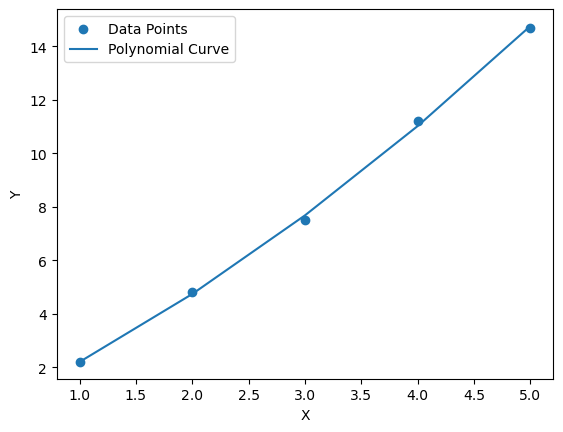

In [3]:
# Q8 : Implement polynomial regression on the following data:
# X = [1, 2, 3, 4, 5]
# Y = [2.2, 4.8, 7.5, 11.2, 14.7]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import PolynomialFeatures
from sklearn.linear_model import LinearRegression

X = np.array([1,2,3,4,5]).reshape(-1,1)
Y = np.array([2.2,4.8,7.5,11.2,14.7])

poly = PolynomialFeatures(degree=2)
X_poly = poly.fit_transform(X)

model = LinearRegression()
model.fit(X_poly,Y)

Y_pred = model.predict(X_poly)

plt.scatter(X,Y,label="Data Points")
plt.plot(X,Y_pred,label="Polynomial Curve")
plt.xlabel("X")
plt.ylabel("Y")
plt.legend()
plt.show()


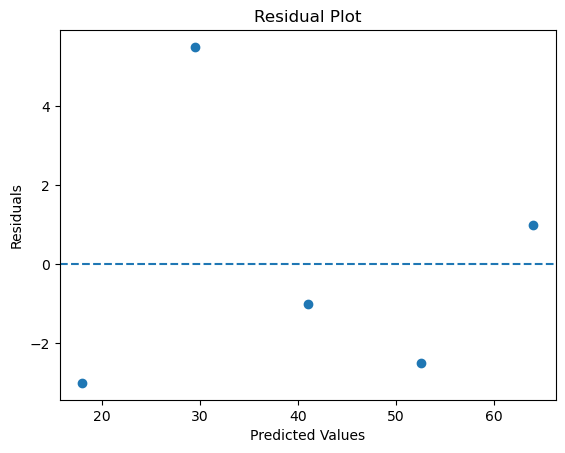

Residuals: [-3.   5.5 -1.  -2.5  1. ]


In [4]:
# Q9 Create a residuals plot for a regression model trained on this data:
# X = [10, 20, 30, 40, 50]
# Y = [15, 35, 40, 50, 65]
import numpy as np
import matplotlib.pyplot as plt
from sklearn.linear_model import LinearRegression

X = np.array([10,20,30,40,50]).reshape(-1,1)
Y = np.array([15,35,40,50,65])

model = LinearRegression()
model.fit(X,Y)

Y_pred = model.predict(X)

residuals = Y - Y_pred

plt.scatter(Y_pred,residuals)
plt.axhline(y=0,linestyle='--')
plt.xlabel("Predicted Values")
plt.ylabel("Residuals")
plt.title("Residual Plot")
plt.show()

print("Residuals:", residuals)

In [ ]:
# Q10  Imagine you are a data scientist working for a real estate company. You need to predict house prices using features like area, number of rooms,
# and location. However, you detect heteroscedasticity and multicollinearity in your regression model. Explain the steps you would take to address 
# these issues and ensure a robust model.
